In [19]:
import numpy as np
import pandas as pd
from importlib import reload
import NpAutograd as npa
from NpAutograd import sigmoid, relu, BCELoss, leaky_relu, logloss, softmax, rmse
from NeuralNetwork import NeuralNetwork
from TrainHelpers import batcher, get_metrics, one_hot
from Optimizers.SGD import SGD, Adam, LambdaSGD
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
def cosine_annealing_schedule(epochs: int, batchsize: int, dataset_length: int, warmup_steps: float = 0.1):
    num_steps = np.ceil(dataset_length / batch_size) * num_epochs
    num_warmup = warmup_steps * num_steps
    def schedule(t):
        if t < num_warmup:
            return t / num_warmup
        else:
            return np.cos((t - num_warmup) / (num_steps - num_warmup) * np.pi / 2)
    return schedule

In [39]:
X = np.linspace(-1, 1, 1_000).reshape(-1, 1)
Y = X**2 + X #Same toy problem as before but now with the power of universal function approximators

In [53]:
neural_net = NeuralNetwork(1,1, activation=sigmoid)

In [54]:
num_epochs = 400
batch_size = 200
schedule = cosine_annealing_schedule(num_epochs, batch_size, len(X))
optim = LambdaSGD(neural_net.get_params(), lr=1e-3, lr_func=schedule)

In [55]:
losses=[]
for i in range(num_epochs):
    batch = batcher(X, Y, batch_size)
    for batch_data, batch_lbl in batch:
        preds = neural_net(batch_data)
        loss = rmse(preds, batch_lbl)
        loss.backward()
        optim.update_params()
        losses.append(loss.v)
    if i % 10 == 0:
        print(f"Epoch {i}: Loss {loss.v}")

Epoch 0: Loss 2.5488792053184177
Epoch 10: Loss 2.6117836345440177
Epoch 20: Loss 2.503194913528361
Epoch 30: Loss 2.1665617433891367
Epoch 40: Loss 1.9548714701821845
Epoch 50: Loss 1.8397190248501938
Epoch 60: Loss 1.6200860818245237
Epoch 70: Loss 1.355347216403142
Epoch 80: Loss 1.1500737398826812
Epoch 90: Loss 1.0274469107660371
Epoch 100: Loss 0.8640436103886777
Epoch 110: Loss 0.7206821228182627
Epoch 120: Loss 0.550709161434642
Epoch 130: Loss 0.4215594309527661
Epoch 140: Loss 0.2755124544451299
Epoch 150: Loss 0.14607052114143318
Epoch 160: Loss 0.058065759529132406
Epoch 170: Loss 0.049061908541632504
Epoch 180: Loss 0.051694644721165015
Epoch 190: Loss 0.043150357541417855
Epoch 200: Loss 0.04014287665549695
Epoch 210: Loss 0.03762391310729782
Epoch 220: Loss 0.034036859363420276
Epoch 230: Loss 0.03513091444782593
Epoch 240: Loss 0.035761818919308436
Epoch 250: Loss 0.027948872472737498
Epoch 260: Loss 0.03183476656834503
Epoch 270: Loss 0.026432464410094267
Epoch 280: Lo

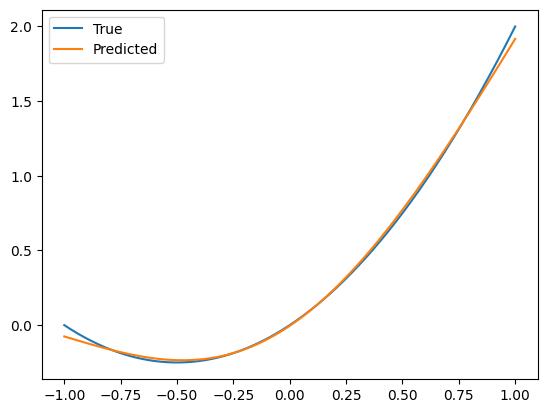

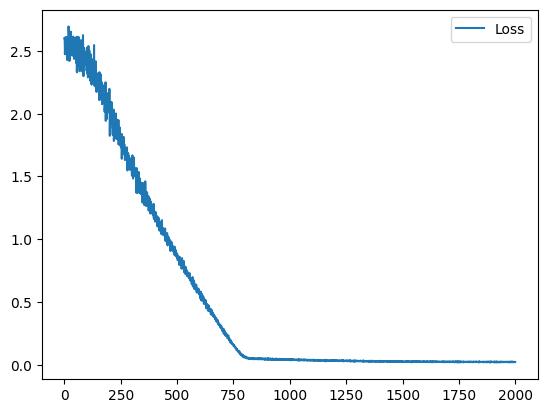

In [57]:
plt.plot(X, Y, label="True")
plt.plot(X, neural_net(X).v, label="Predicted")
plt.legend()
plt.show()
plt.plot(losses, label="Loss")
plt.legend()
plt.show()

In [3]:
mnist_train = pd.read_csv("data/mnist_train.csv", header=None).to_numpy(dtype=np.float32)
train_labels, train_data = mnist_train[:,0], mnist_train[:,1:]
train_data = train_data / 255.
train_labels = one_hot(train_labels.astype(np.int32), 10)
test_data = pd.read_csv("data/mnist_test.csv", header=None).to_numpy(dtype=np.float32)
test_labels, test_data = test_data[:,0], test_data[:,1:]
test_data = test_data / 255.
test_labels = one_hot(test_labels.astype(np.int32), 10)

In [ ]:
neural_net = NeuralNetwork(784, 10, activation=leaky_relu)

In [10]:
num_epochs = 200
batch_size = 256
num_steps = np.ceil(len(train_data) / batch_size) * num_epochs
warmup_steps = 0.1 * num_steps
def schedule(t):
    if t < warmup_steps:
        return t / warmup_steps
    else:
        return np.cos((t - warmup_steps) / (num_steps - warmup_steps) * np.pi / 2)

optim = LambdaSGD(neural_net.get_params(), lr=1e-3, lr_func=schedule)

In [11]:
for i in range(num_epochs):
    batch = batcher(train_data, train_labels, 256)
    for batch_data, batch_lbl in batch:
        logits = neural_net(batch_data)
        loss = logloss(logits, batch_lbl)
        loss.backward()
        optim.update_params()
    if i % 10 == 0:
        print(f"Epoch {i}: Loss {loss.v}")

Epoch 0: Loss 14.39186008929862
Epoch 10: Loss 16.469548232928346
Epoch 20: Loss 11.465706480855516
Epoch 30: Loss 12.261559966632761
Epoch 40: Loss 12.414114841366382
Epoch 50: Loss 13.18862139569715
Epoch 60: Loss 15.520568360838368
Epoch 70: Loss 15.380414922867288
Epoch 80: Loss 16.45001190188493
Epoch 90: Loss 17.31293495075737
Epoch 100: Loss 13.564002311130404
Epoch 110: Loss 9.161137474493431
Epoch 120: Loss 13.682624886970396
Epoch 130: Loss 13.48983717562053
Epoch 140: Loss 14.593666467492971
Epoch 150: Loss 11.242777409442946
Epoch 160: Loss 15.646615922702678
Epoch 170: Loss 14.537205542329268
Epoch 180: Loss 10.736795094518863
Epoch 190: Loss 12.739617204410768


In [12]:
preds = softmax(neural_net(train_data)).v
get_metrics(preds, train_labels)

{'confusion_matrix': array([[   0,    0,  438,  387,   28, 3429,  478,    0,  769,  394],
        [   0, 6499,   68,   49,   16,   24,   11,    0,   46,   29],
        [   1,   45, 5331,  128,  112,   46,   80,    0,  174,   41],
        [   0,   32,  192, 5431,   14,  189,   41,    0,  128,  104],
        [   2,   24,   21,   10, 5463,   16,   62,    0,   51,  193],
        [   1,   29,   52,  212,   53, 4694,  102,    0,  193,   85],
        [   4,   22,   43,   15,   56,   80, 5650,    1,   42,    5],
        [  20,   82,  431,  335,  554,   84,    7,    0,  143, 4609],
        [   0,   71,   73,  186,   30,  190,   45,    0, 5184,   72],
        [   0,    6,   54,  113,  143,   66,   13,    0,   67, 5487]]),
 'per_class': {'accuracy': array([0.        , 0.10831667, 0.08885   , 0.09051667, 0.09105   ,
         0.07823333, 0.09416667, 0.        , 0.0864    , 0.09145   ]),
  'precision': array([0.        , 0.95433186, 0.79531553, 0.79099913, 0.8444891 ,
         0.53232025, 0.87070427

In [28]:
a = np.array([1., 2.])
b = npa.Tensor(np.array([3., 4.]))
2. ** b

(array([ 2., 10., 19., 44., 58., 45., 36., 22., 14.,  6.]),
 array([-2.60378772, -2.09016426, -1.5765408 , -1.06291734, -0.54929388,
        -0.03567041,  0.47795305,  0.99157651,  1.50519997,  2.01882343,
         2.53244689]),
 <BarContainer object of 10 artists>)

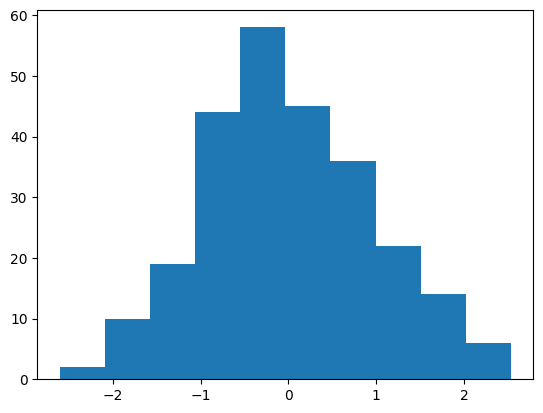

In [30]:
plt.hist(neural_net.layers[0].weights.v.flatten(), bins=10)

In [8]:
optim.params

In [9]:
neural_net.layers[0].get_params()

[<NpAutograd.Tensor at 0x111b34fb0>, <NpAutograd.Tensor at 0x111b06600>]

In [10]:
a = [1,2]
b =[]
b.extend(a)
b

[1, 2]